In [1]:
import os

gadf_base_dir = r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN\Images\GADF"
gasf_base_dir = r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN\Images\GASF"

print(os.listdir(gadf_base_dir))
print(os.listdir(gasf_base_dir))

['test', 'train', 'val']
['test', 'train', 'val']


In [2]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
# gadf_train_dir = os.path.join(gadf_base_dir, "train")
# gadf_val_dir = os.path.join(gadf_base_dir, "val")
# gadf_test_dir = os.path.join(gadf_base_dir, "test")

gasf_train_dir = os.path.join(gasf_base_dir, "train")
gasf_val_dir = os.path.join(gasf_base_dir, "val")
gasf_test_dir = os.path.join(gasf_base_dir, "test")

In [5]:
print("GASF classes:", os.listdir(gasf_train_dir))
# print("GASF classes:", os.listdir(gasf_train_dir))

GASF classes: ['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']


In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [7]:
def get_samples(gaf_split_dir):

    samples = []

    classes = sorted([
        d for d in os.listdir(gaf_split_dir)
        if os.path.isdir(os.path.join(gaf_split_dir, d))
    ])

    print(classes)

    for class_name in classes:

        gaf_class_dir = os.path.join(gaf_split_dir, class_name)

        images = sorted([
            i for i in os.listdir(gaf_class_dir)
            if i.lower().endswith(".png")
        ])

        for img in images:

            gaf_path = os.path.join(gaf_class_dir, img)

            samples.append((gaf_path, class_name))

    return samples

In [8]:
train = get_samples(gasf_train_dir)

val = get_samples(gasf_val_dir)

test = get_samples(gasf_test_dir)

['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']
['B_007', 'B_014', 'B_021', 'IR_007', 'IR_014', 'IR_021', 'Normal', 'OR_007', 'OR_014', 'OR_021']


In [9]:
print("TRAIN :", len(train))
print("VAL   :", len(val))
print("TEST  :", len(test))

TRAIN : 6604
VAL   : 681
TEST  : 681


In [10]:
class_to_idx = {}
idx = 0

classes = sorted([
    d for d in os.listdir(gasf_train_dir)
    if os.path.isdir(os.path.join(gasf_train_dir, d))
])

for cls in classes:
  class_to_idx[cls] = idx
  idx += 1

print(class_to_idx)

{'B_007': 0, 'B_014': 1, 'B_021': 2, 'IR_007': 3, 'IR_014': 4, 'IR_021': 5, 'Normal': 6, 'OR_007': 7, 'OR_014': 8, 'OR_021': 9}


In [11]:
class BearingData(Dataset):

  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    image_path, class_name = self.features[idx]
    image = Image.open(image_path).convert("L")

    if self.transform:
      image = self.transform(image)

    label = class_to_idx[class_name]

    return image, torch.tensor(label, dtype=torch.long)

In [12]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [13]:
train_dataset = BearingData(train, class_to_idx, transform)

val_dataset = BearingData(val, class_to_idx, transform)

test_dataset = BearingData(test, class_to_idx, transform)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [15]:
images, labels = next(iter(train_loader))

print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Image dtype :", images.dtype)
print("Labels      :", labels[:10])

Image shape : torch.Size([32, 1, 224, 224])
Label shape : torch.Size([32])
Image dtype : torch.float32
Labels      : tensor([5, 9, 9, 1, 3, 9, 9, 6, 5, 1])


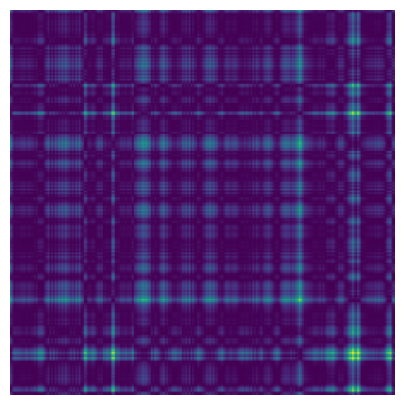

In [16]:
import matplotlib.pyplot as plt

idx_to_class = {v: k for k, v in class_to_idx.items()}
image, label = train_dataset[0]

plt.figure(figsize=(5, 5))

plt.imshow(
    image.squeeze(0)
)

plt.axis("off")
plt.show()

In [17]:
class FaultDiagnosis(nn.Module):

  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.3),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Dropout(0.3),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(2, 2)
    )

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),

        nn.Flatten(),

        nn.Linear(in_features=128, out_features=64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(in_features=64, out_features=32),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(in_features=32, out_features=10)
    )

  def forward(self, x):
    x = self.network(x)
    x = self.classifier(x)
    return x

In [18]:
model = FaultDiagnosis().to(device)

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 50

In [20]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

In [21]:
print("Training started")

for epoch in range(epochs):

  model.train()

  correct = 0
  total = 0
  running_loss = 0.0

  for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(inputs)

    loss = criterion(outputs, labels)

    loss.backward()
    
    optimizer.step()

    running_loss += loss.item()*inputs.size(0)
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_loss = running_loss / total
  train_accuracy = 100*correct / total

  print("\nValidation started\n")

  model.eval()

  with torch.no_grad():
    correct = 0
    total = 0
    running_loss = 0.0

    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)

      loss = criterion(outputs, labels)

      running_loss += loss.item()*inputs.size(0)
      _, predicted = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    val_loss = running_loss / total
    val_accuracy = 100*correct / total

    if val_accuracy > best_val_accuracy:

      best_val_accuracy = val_accuracy

      torch.save(model.state_dict(),"3layer_gasf_best_weights_model.pth")

      print(f"New best validation accuracy: {best_val_accuracy:.2f}%")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] ")
    print(f"Train Loss: {train_loss:.4f} ")
    print(f"Train Acc: {train_accuracy:.2f}% ")
    print(f"Val Loss: {val_loss:.4f} ")
    print(f"Val Acc: {val_accuracy:.2f}%")

print("Training complete .....")

Training started

Validation started

New best validation accuracy: 47.28%
Epoch [1/50] 
Train Loss: 1.4885 
Train Acc: 46.38% 
Val Loss: 1.5332 
Val Acc: 47.28%

Validation started

New best validation accuracy: 57.27%
Epoch [2/50] 
Train Loss: 0.9224 
Train Acc: 67.00% 
Val Loss: 1.2589 
Val Acc: 57.27%

Validation started

New best validation accuracy: 67.40%
Epoch [3/50] 
Train Loss: 0.7568 
Train Acc: 73.86% 
Val Loss: 0.9233 
Val Acc: 67.40%

Validation started

Epoch [4/50] 
Train Loss: 0.6307 
Train Acc: 77.59% 
Val Loss: 1.0949 
Val Acc: 66.81%

Validation started

New best validation accuracy: 76.65%
Epoch [5/50] 
Train Loss: 0.5611 
Train Acc: 80.60% 
Val Loss: 0.6696 
Val Acc: 76.65%

Validation started

Epoch [6/50] 
Train Loss: 0.4996 
Train Acc: 82.33% 
Val Loss: 1.0368 
Val Acc: 70.19%

Validation started

Epoch [7/50] 
Train Loss: 0.4697 
Train Acc: 83.90% 
Val Loss: 1.0380 
Val Acc: 68.58%

Validation started

New best validation accuracy: 87.22%
Epoch [8/50] 
Train L

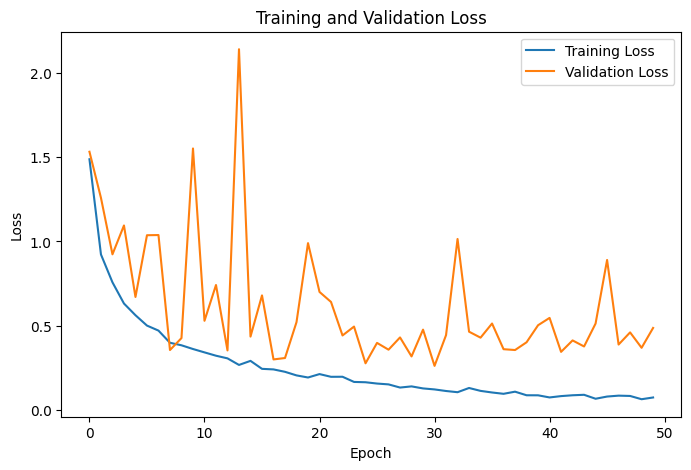

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

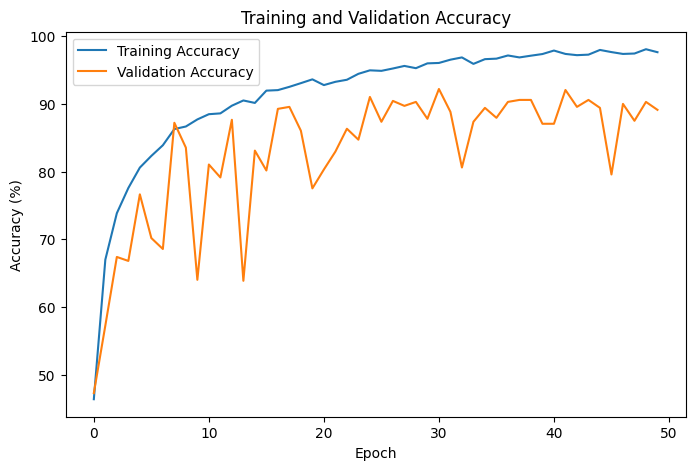

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

In [30]:
model = FaultDiagnosis().to(device)

model.load_state_dict(
    torch.load(
        r"C:\Users\ankus\OneDrive\Documents\222026\IT\Awdhootprasad\Kurtosis\2D_CNN\notebooks\3layer_gasf_best_weights_model.pth",
        weights_only=True
    )
)

<All keys matched successfully>

In [31]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print(f"Training Accuracy: {test_accuracy:.2f}%")

Training Accuracy: 98.68%


In [32]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for inputs, labels in val_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (
            predicted == labels
        ).sum().item()

test_accuracy = 100 * test_correct / test_total

print(f"Val Accuracy: {test_accuracy:.2f}%")

Val Accuracy: 92.22%


In [33]:
model.eval()

test_correct = 0
test_total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


test_accuracy = 100 * test_correct / test_total

print(f"Test Accuracy: {test_accuracy:.2f}%")

all_labels = np.array(all_labels)

all_predictions = np.array(all_predictions)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

Test Accuracy: 90.16%
[[59  5  1  2  0  0  0  0  1  0]
 [ 4 40  7  7  6  0  0  0  4  0]
 [ 3  4 53  1  2  1  0  0  4  0]
 [ 0  4  1 63  1  0  0  0  0  0]
 [ 0  3  0  0 63  1  0  1  0  0]
 [ 0  1  0  0  1 66  0  0  0  0]
 [ 0  0  0  0  0  0 68  0  0  0]
 [ 0  0  0  0  0  0  0 68  0  0]
 [ 0  0  0  0  0  0  0  0 68  0]
 [ 0  0  0  0  1  1  0  0  0 66]]


In [34]:
class_names = [
    "B_007",
    "B_014",
    "B_021",
    "IR_007",
    "IR_014",
    "IR_021",
    "Normal",
    "OR_007",
    "OR_014",
    "OR_021"
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       B_007     0.8939    0.8676    0.8806        68
       B_014     0.7018    0.5882    0.6400        68
       B_021     0.8548    0.7794    0.8154        68
      IR_007     0.8630    0.9130    0.8873        69
      IR_014     0.8514    0.9265    0.8873        68
      IR_021     0.9565    0.9706    0.9635        68
      Normal     1.0000    1.0000    1.0000        68
      OR_007     0.9855    1.0000    0.9927        68
      OR_014     0.8831    1.0000    0.9379        68
      OR_021     1.0000    0.9706    0.9851        68

    accuracy                         0.9016       681
   macro avg     0.8990    0.9016    0.8990       681
weighted avg     0.8990    0.9016    0.8990       681



In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": 100,
}, "3layer_gadf_fault_diagnosis_cnn_2D_e100.pth")

# **Resnet training and testing pipeline**



In [ ]:
from torchvision import models, transforms

weights = models.ResNet18_Weights.DEFAULT
model_resnet = models.resnet18(weights=None).to(device)

print(model_resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
model_resnet.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)
model_resnet.to(device)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
resnet_transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
#for params in model_resnet.parameters():
  #params.requires_grad = False

In [ ]:
resnet_optimizer = torch.optim.Adam(model_resnet.parameters(),lr=1e-4)

resnet_criterion = nn.CrossEntropyLoss()

resnet_best_val_accuracy = 0.0

resnet_epochs = 50

In [ ]:
print("Training Started .......")

for epoch in range(resnet_epochs):
  correct = 0.0
  total = 0.0
  running_loss = 0.0

  model_resnet.train()

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    resnet_optimizer.zero_grad()

    outputs = model_resnet(inputs)

    loss = resnet_criterion(outputs, labels)

    loss.backward()

    resnet_optimizer.step()

    running_loss += loss.item()*inputs.size(0)

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_accuracy = 100 * correct / total
  train_loss = running_loss / total

  print("\nValidation Started .......")

  model_resnet.eval()

  with torch.no_grad():
    correct = 0.0
    total = 0.0
    running_loss = 0.0

    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model_resnet(inputs)

      loss = resnet_criterion(outputs, labels)

      _, predicted = torch.max(outputs, 1)

      running_loss += loss.item()*inputs.size(0)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_accuracy = 100 * correct / total
  val_loss = running_loss / total

  if val_accuracy > resnet_best_val_accuracy:

      resnet_best_val_accuracy = val_accuracy

      torch.save(model.state_dict(),"resnet_gadf_best_weights.pth")

      print(f"New best validation accuracy: {resnet_best_val_accuracy:.2f}%")

  print(f"Epoch [{epoch + 1}/{resnet_epochs}]")
  print(f"Training loss : {train_loss:.4f}")
  print(f"Training accurcay : {train_accuracy:.2f}%")
  print(f"Validation loss : {val_loss:.4f}")
  print(f"Validation accurcay : {val_accuracy:.2f}%")

print("Training Completed!!")

Training Started .......

Validation Started .......
New best validation accuracy: 77.24%
Epoch [1/50]
Training loss : 0.8517
Training accurcay : 68.99%
Validation loss : 0.6107
Validation accurcay : 77.24%

Validation Started .......
New best validation accuracy: 85.46%
Epoch [2/50]
Training loss : 0.3180
Training accurcay : 88.86%
Validation loss : 0.3873
Validation accurcay : 85.46%

Validation Started .......
Epoch [3/50]
Training loss : 0.1929
Training accurcay : 93.46%
Validation loss : 0.4237
Validation accurcay : 84.73%

Validation Started .......
Epoch [4/50]
Training loss : 0.1178
Training accurcay : 96.21%
Validation loss : 0.5993
Validation accurcay : 81.79%

Validation Started .......
New best validation accuracy: 86.05%
Epoch [5/50]
Training loss : 0.0639
Training accurcay : 98.21%
Validation loss : 0.4761
Validation accurcay : 86.05%

Validation Started .......
New best validation accuracy: 88.84%
Epoch [6/50]
Training loss : 0.0612
Training accurcay : 98.09%
Validation 

In [ ]:
print("Testing Started .......")

model_resnet.eval()

correct = 0.0
total = 0.0

all_predictions = []
all_labels = []

for inputs, labels in test_loader:
  inputs, labels = inputs.to(device), labels.to(device)

  outputs = model_resnet(inputs)

  _, predicted = torch.max(outputs, 1)

  total += labels.size(0)
  correct += (predicted == labels).sum().item()

  all_labels.extend(labels.cpu().numpy())
  all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total
test_loss = running_loss / total

all_labels = np.array(all_labels)

all_predictions = np.array(all_predictions)

print(f"Training accuracy : {test_accuracy}")

Testing Started .......
Training accuracy : 86.06060606060606


In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)